In [ ]:
from matplotlib import pyplot as plt
from microsync.microsync import SyncDevice


In [4]:
import pyvisa
TEK_VID_PID="0x0699::0x0365"

rc = pyvisa.ResourceManager()

for r in rc.list_resources_info():
    if TEK_VID_PID in r:
        scope = rc.open_resource(r)

In [5]:
from microsync.tektronix import TDS2004

In [ ]:
tek = TDS2004(scope)
sd = SyncDevice("COM3")

In [22]:
us = 1e-6

In [24]:
tek.hscale = 10*us
tek.hpos = 30*us

## High-speed ALEX acquisition, 2-channels

We set the time delay for shutter to 100us, and camera readout time to 200us.

In [69]:
sd.cam_readout_us = 20
sd.shutter_delay_us = 10

In [71]:
# Configure the oscilloscope
# Setup channel 1
tek.io.write("select:ch1 on") # camera channel
tek.io.write("ch1:probe 1") # camera channel
tek.ch[1].scale = 1 # V/div
tek.ch[1].position = -3 # V

# Setup channel 2
tek.io.write("select:ch2 on") # Cy3 channel
tek.ch[2].scale = 1 # V/div
tek.ch[2].position = -2.1 # V

# Setup channel 3
tek.io.write("select:ch2 on") # Cy5 channel
tek.ch[3].scale = 1 # V/div
tek.ch[3].position = -1.9 # V

# Horizontal setup
tek.trig.source = 'CH2'  # Cy3 channel
tek.trig.level = 2.8
tek.hscale = 25*us
tek.hpos = 30*us

In [64]:
tek.trig.mode = 'NORM'
tek.acq.stopafter = 'RUNSTOP'
tek.acq.run()

In [72]:
sd.selected_lasers=0b0110
sd.interlock_enabled = False
sd.cam_level_trigger_mode = 1

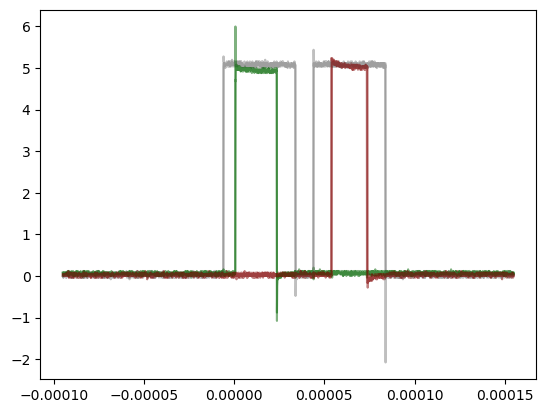

In [81]:
for i in range(2):
    sd.start_ALEX_acq(exp_time=20, N_bursts=1)
    plt.plot(*tek.read_curve(1), color='grey', alpha=0.5)
    plt.plot(*tek.read_curve(2), color='darkgreen', alpha=0.5)
    plt.plot(*tek.read_curve(3), color='maroon', alpha=0.5);

plt.show()